In [ ]:

import sys
sys.path.append('/Users/owenmeyer/dsp-modeler')
print(sys.path)

['/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python314.zip', '/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14', '/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/lib-dynload', '', '/Users/owenmeyer/dsp-modeler/.venv/lib/python3.14/site-packages', '/Users/owenmeyer/dsp-modeler/black-box']


In [ ]:
from train import Track, DataSet
import torch

In [8]:
param_names=["d", "f", "v"]
param_configs={
    'd':{'min':1, 'max':7, 'dtype':torch.float32},
    'f':{'min':1, 'max':7, 'dtype':torch.float32},
    'v':{'min':1, 'max':7, 'dtype':torch.float32},
}

In [7]:
train_dataset = DataSet(
    '/home/ubuntu/dsp-modeler/data/outputs/manifest.jsonl', 
    '/home/ubuntu/dsp-modeler/data/input/input.wav', 
    '/home/ubuntu/dsp-modeler/data/outputs', 
    0.03, 
    ["d", "f", "v"], 
    {'d':{'min':1, 'max':7, 'dtype':torch.float32},'f':{'min':1, 'max':7, 'dtype':torch.float32},'v':{'min':1, 'max':7, 'dtype':torch.float32}}, 
    silent_lead_in_seconds=8, 
    trim_noise = True
)

For /home/ubuntu/dsp-modeler/data/outputs/a4c49ad9-6ff5-4287-80a1-0d7ae2028d70.wav

+12608 samples (+131.328 ms)
12607
n_samples 23411393 w n_chunks 8128
For /home/ubuntu/dsp-modeler/data/outputs/95acc994-d2f5-40a8-8ea1-fe873eccf4a5.wav

+12606 samples (+131.307 ms)
12605
n_samples 23411395 w n_chunks 8128
For /home/ubuntu/dsp-modeler/data/outputs/2a8704b9-0e6d-46f1-a910-96df3e7f3c12.wav

-25462 samples (-265.229 ms)
-25462
n_samples 23398538 w n_chunks 8124
For /home/ubuntu/dsp-modeler/data/outputs/8306953c-daff-40e5-a363-2c648ead8437.wav

+62712 samples (+653.250 ms)
62712
n_samples 23361288 w n_chunks 8111
For /home/ubuntu/dsp-modeler/data/outputs/a8747186-e3ce-4327-b144-0346bcea7550.wav

-19040 samples (-198.333 ms)
-19040
n_samples 23404960 w n_chunks 8126
For /home/ubuntu/dsp-modeler/data/outputs/b150a563-244f-499e-9957-9af49a7d3595.wav

-77842 samples (-810.854 ms)
-77842
n_samples 23346158 w n_chunks 8106
For /home/ubuntu/dsp-modeler/data/outputs/fbed9477-c92a-4901-99f3-111417f

In [13]:
import matplotlib
print(matplotlib.get_backend())

Agg


In [16]:
rows = []
for track in train_dataset:
    row=[]
    params = track[0][0].params
    for p in param_names:
        row.append(params[p])

    gain = track.compute_wet_gain()
    row.append(float(gain))
    
    # noise_profile = track[0].noise_profile
    # row.append[noise_profile[0][0]]


    rows.append(row)

In [17]:
rows

[[4.0, 4.0, 6.0, 0.43911489844322205],
 [4.0, 4.0, 7.0, 0.8567544221878052],
 [1.0, 1.0, 1.0, 3.687506978167221e-05],
 [1.0, 3.0, 1.0, 3.7460122257471085e-05],
 [1.0, 5.0, 1.0, 3.7479399907169864e-05],
 [1.0, 7.0, 1.0, 3.754878343897872e-05],
 [1.0, 1.0, 3.0, 0.0007683449657633901],
 [1.0, 1.0, 5.0, 0.003593521425500512],
 [1.0, 1.0, 7.0, 0.02020937390625477],
 [1.0, 3.0, 3.0, 0.0006669199792668223],
 [1.0, 3.0, 5.0, 0.0034218034707009792],
 [1.0, 3.0, 7.0, 0.021725960075855255],
 [1.0, 5.0, 3.0, 0.0006220475770533085],
 [1.0, 5.0, 5.0, 0.0036298418417572975],
 [1.0, 5.0, 7.0, 0.020080916583538055],
 [1.0, 7.0, 3.0, 0.0005854006158187985],
 [1.0, 7.0, 5.0, 0.0028802708256989717],
 [1.0, 7.0, 7.0, 0.01750212162733078],
 [3.0, 1.0, 1.0, 4.3310210458002985e-05],
 [3.0, 3.0, 1.0, 4.25998296122998e-05],
 [3.0, 5.0, 1.0, 4.27193044743035e-05],
 [3.0, 7.0, 1.0, 3.8929130823817104e-05],
 [3.0, 1.0, 3.0, 0.02219834364950657],
 [3.0, 3.0, 3.0, 0.02205759845674038],
 [3.0, 5.0, 3.0, 0.01872614026

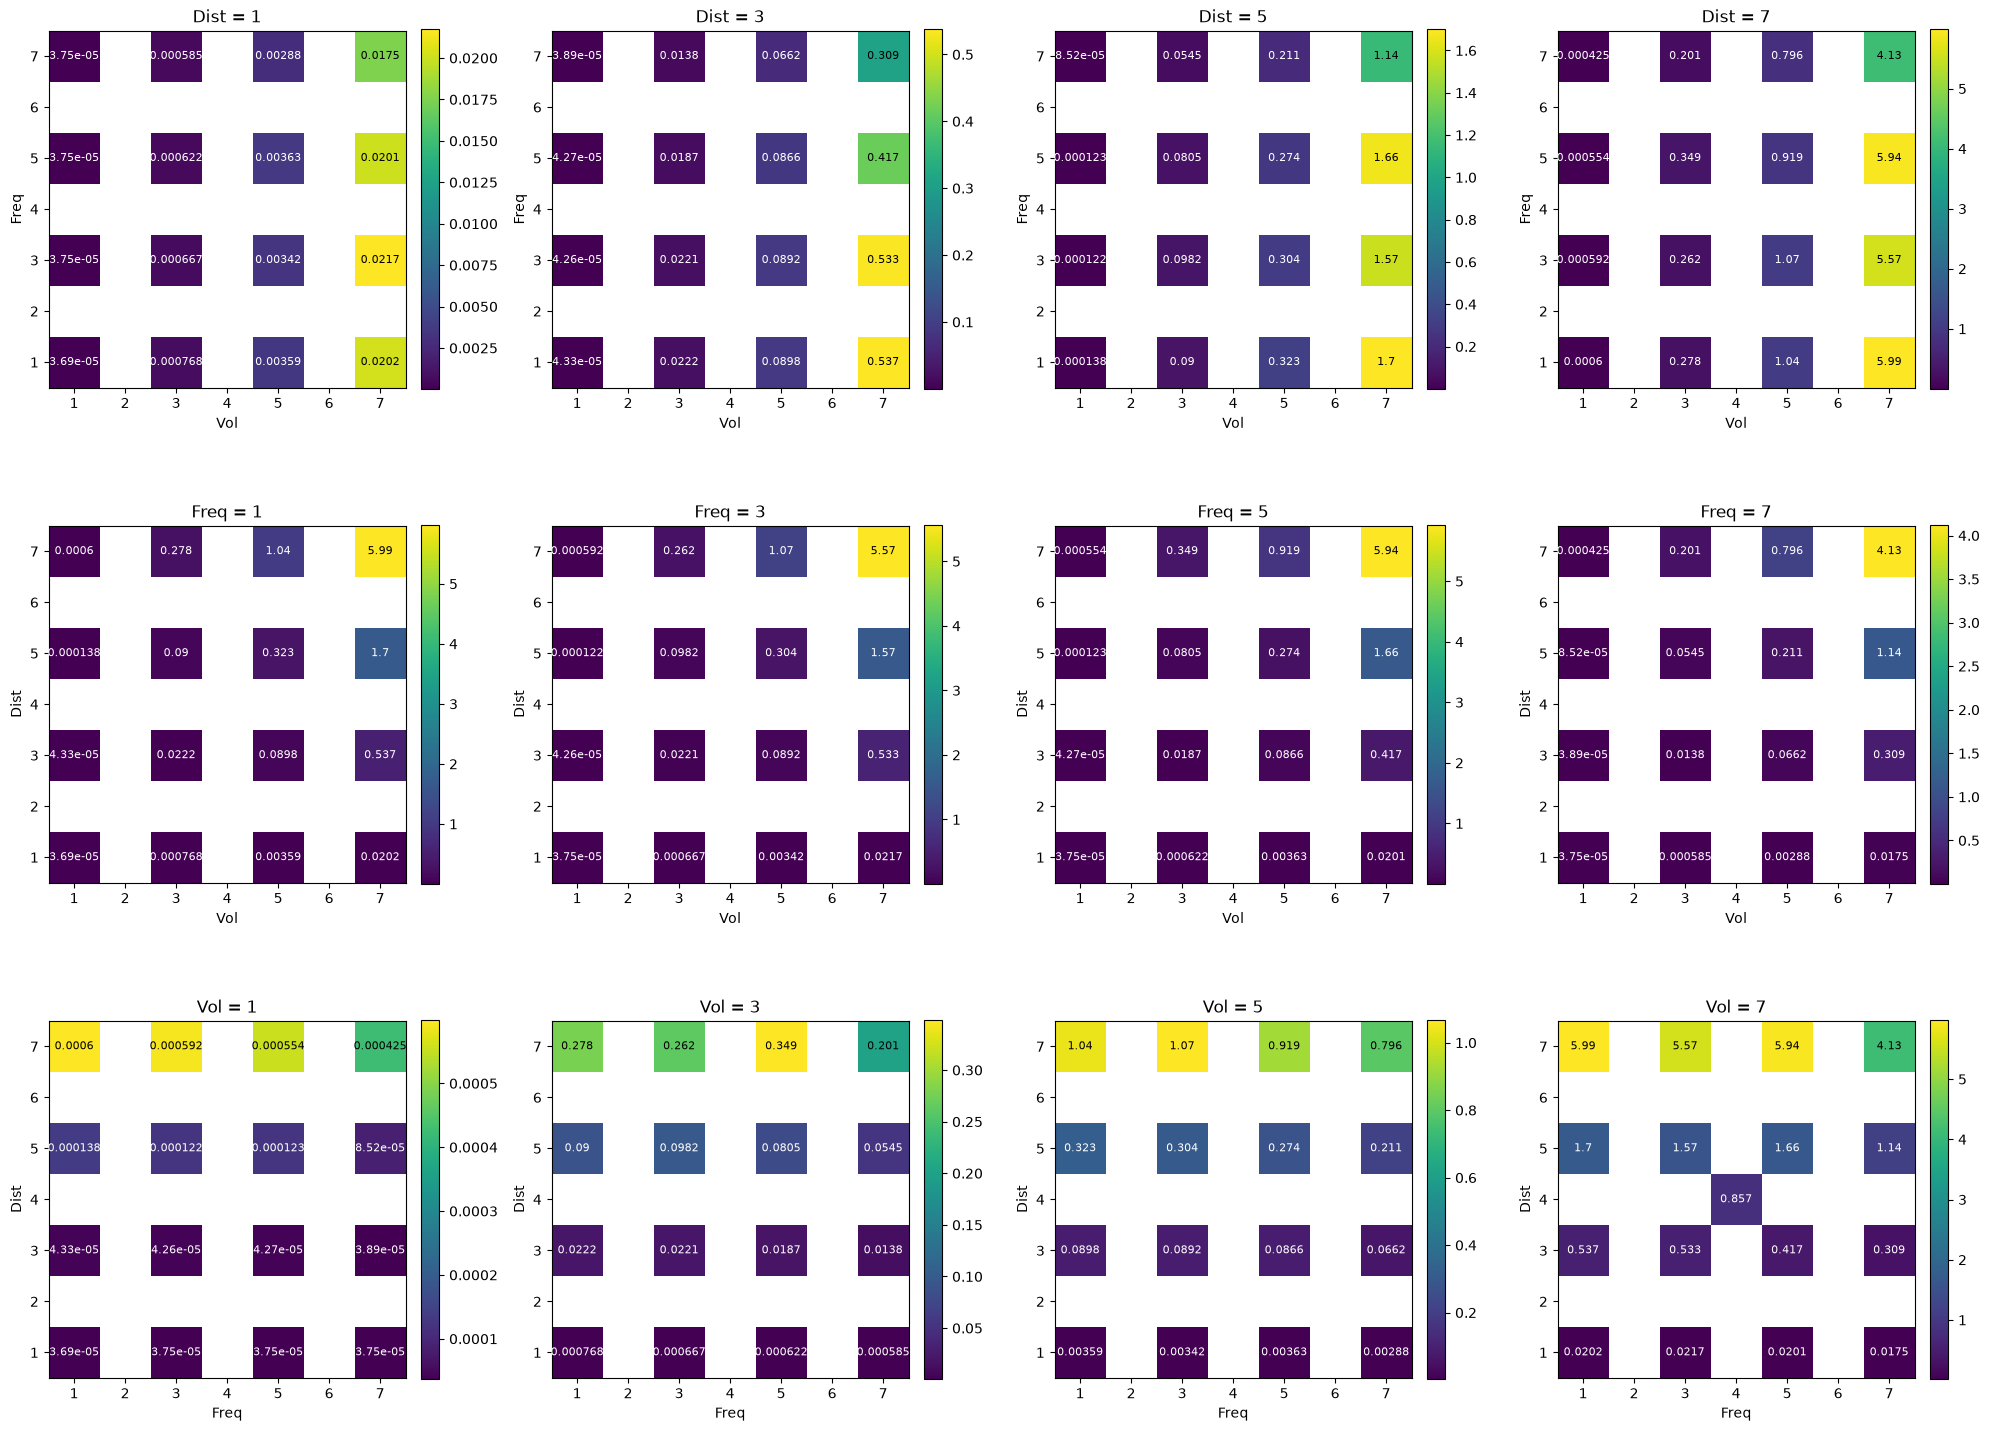

In [27]:
param_names = ['Dist', 'Freq', 'Vol']

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def plot_gain_grids(data, const_vals=(1, 3, 5, 7), grid_range=range(1, 8), save_path=None):
    """
    data: list of [param_1_val, param_2_val, param_3_val, gain_val] rows.
    Row 0: param_1_val held constant per column -> axes (param_2_val, param_3_val)
    Row 1: param_2_val held constant per column -> axes (param_1_val, param_3_val)
    Row 2: param_3_val held constant per column -> axes (param_1_val, param_2_val)
    save_path: if given, saves the figure to this path (e.g. 'gain_grids.png').
    """
    grid_range = list(grid_range)
    n = len(grid_range)
    idx = {v: i for i, v in enumerate(grid_range)}
    param_names = ['Dist', 'Freq', 'Vol']

    row_configs = [
        (0, 1, 2),
        (1, 0, 2),
        (2, 0, 1),
    ]

    fig, axes = plt.subplots(3, len(const_vals), figsize=(5 * len(const_vals), 15))

    for row, (const_idx, row_idx, col_idx) in enumerate(row_configs):
        for col, const_v in enumerate(const_vals):
            ax = axes[row, col]
            grid = np.full((n, n), np.nan)
            for r in data:
                params, gain = r[:3], r[3]
                if params[const_idx] != const_v:
                    continue
                rv, cv = params[row_idx], params[col_idx]
                if rv in idx and cv in idx:
                    grid[idx[rv], idx[cv]] = gain

            im = ax.imshow(grid, cmap='viridis', origin='lower')
            ax.set_xticks(range(n)); ax.set_xticklabels(grid_range)
            ax.set_yticks(range(n)); ax.set_yticklabels(grid_range)
            ax.set_xlabel(param_names[col_idx])
            ax.set_ylabel(param_names[row_idx])
            ax.set_title(f'{param_names[const_idx]} = {const_v}')

            for i in range(n):
                for j in range(n):
                    val = grid[i, j]
                    if not np.isnan(val):
                        norm_val = im.norm(val)
                        text_color = 'black' if norm_val > 0.5 else 'white'
                        ax.text(j, i, f'{val:.3g}', ha='center', va='center',
                                color=text_color, fontsize=8)

            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

plot_gain_grids(rows, const_vals=(1, 3, 5, 7), grid_range=range(1, 8), save_path='/home/ubuntu/dsp-modeler/black_box/train/viz/params.png')